# From Predictive Returns to an Optimal Trade
## Position Sizing under Risk, Costs and Liquidity Constraints

A forecasting model can estimate a distribution of possible future returns, but a return forecast is not yet a trading decision.

This notebook studies the next question:

> **Given a predictive return distribution, what position should an investor take after accounting for uncertainty, trading costs, liquidity and portfolio constraints?**

Let:

$$
q\in\mathbb R
$$

denote the dollar position.

The sign of $q$ determines the trade direction:

$$
q>0
\quad\Rightarrow\quad
\text{long position},
$$

$$
q<0
\quad\Rightarrow\quad
\text{short position}.
$$

Portfolio wealth is denoted by:

$$
W>0.
$$

The uncertain future return is represented by:

$$
\tilde R,
$$

and the notebook receives it through predictive draws:

$$
r_1,r_2,\ldots,r_N.
$$

The optimizer does not need to know how these draws were generated. They may come from an event study, an abnormal-return model, a bootstrap, a Bayesian model, or another forecasting method.

The general pipeline is:

$$
\boxed{\text{Predictive Return Distribution}}
\rightarrow
\boxed{\text{Trade Economics}}
\rightarrow
\boxed{\text{Risk-Adjusted Position}}
\rightarrow
\boxed{\text{Practical Constraints}}
\rightarrow
\boxed{q^*}.
$$

If the estimated inputs are themselves uncertain, the complete optimization can be repeated across statistically plausible input states:

$$
\theta^{(1)},\theta^{(2)},\ldots,\theta^{(B)},
$$

producing:

$$
\boxed{
q^{*(1)},q^{*(2)},\ldots,q^{*(B)}
}
$$

rather than treating one optimal position as perfectly known.

### Input taxonomy

The notebook keeps three different sources of information separate.

**Model-estimated inputs** describe the investment opportunity:

$$
\text{return distribution}.
$$

**Market-estimated inputs** describe implementation:

$$
\text{transaction costs},
\qquad
\text{market impact},
\qquad
\text{liquidity}.
$$

**Investor-policy inputs** describe the investor or mandate:

$$
W,\qquad
\rho,\qquad
L,\qquad
\phi,\qquad
H,
$$

where:

- $W$ is portfolio value;
- $\rho$ is relative risk aversion;
- $L$ is the maximum tolerated loss;
- $\phi$ is the maximum allowed participation in daily dollar volume;
- $H$ is the available execution horizon.

This separation is important: investor preferences should not be presented as if they were estimated market parameters.


## 1. Environment Setup


In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar, minimize
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Display settings
pd.options.display.float_format = '{:,.4f}'.format
np.set_printoptions(precision=4, suppress=True)

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.facecolor'] = '#0a0a0a'
plt.rcParams['axes.facecolor'] = '#0a0a0a'
plt.rcParams['savefig.facecolor'] = '#0a0a0a'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

COLORS = {
    'primary': '#2ecc71',
    'secondary': '#3498db',
    'accent': '#e74c3c',
    'neutral': '#95a5a6',
}

print('Environment configured.')
print(f'Random seed: {RANDOM_SEED}')


Environment configured.
Random seed: 42


## 2. Predictive Return Distribution

The main input to the trade-design model is the uncertain future return:

$$
\tilde R.
$$

Rather than assuming a specific probability distribution, the notebook represents this uncertainty through predictive draws:

$$
r_1,r_2,\ldots,r_N.
$$

These draws may come from any upstream model.

The predictive mean is estimated by:

$$
\boxed{
\hat\mu_R
=
\frac{1}{N}
\sum_{i=1}^{N}r_i
}
$$

and the predictive variance by:

$$
\boxed{
\hat\sigma_R^2
=
\frac{1}{N-1}
\sum_{i=1}^{N}
(r_i-\hat\mu_R)^2.
}
$$

The mean describes the expected direction and magnitude of the return, while the variance measures how dispersed the possible outcomes are.

Importantly, the optimizer does not require:

$$
\hat\mu_R>0.
$$

A positive expected return may support a long position, while a negative expected return may support a short position. Trade direction will be determined later by the optimization problem.

No normal-distribution assumption is imposed. The full set of predictive draws is retained.


In [358]:
def summarize_return_distribution(return_draws):
    '''
    Summarize an arbitrary predictive return distribution.
    '''

    returns = np.asarray(
        return_draws,
        dtype=float,
    )

    if returns.ndim != 1:
        raise ValueError(
            'return_draws must be one-dimensional.'
        )

    if len(returns) < 2:
        raise ValueError(
            'At least two return draws are required.'
        )

    if not np.isfinite(returns).all():
        raise ValueError(
            'return_draws contain NaN or infinite values.'
        )

    return {
        'mean_return': returns.mean(),
        'median_return': np.median(returns),
        'return_variance': returns.var(ddof=1),
        'return_std': returns.std(ddof=1),
        'q05_return': np.quantile(returns, 0.05),
        'q95_return': np.quantile(returns, 0.95),
        'min_return': returns.min(),
        'max_return': returns.max(),
        'n_draws': len(returns),
    }


def binary_return_draws(
    p,
    r_event,
    r_no_event,
    n_draws,
    rng,
):
    '''
    Educational helper:
    generate predictive returns from a two-state model.
    '''

    if not 0 <= p <= 1:
        raise ValueError(
            'p must lie between 0 and 1.'
        )

    if n_draws < 2:
        raise ValueError(
            'n_draws must be at least 2.'
        )

    event_occurs = (
        rng.random(n_draws) < p
    )

    return np.where(
        event_occurs,
        r_event,
        r_no_event,
    )

# ============================================================
# EDUCATIONAL BINARY EXAMPLE
# Synthetic values only — not empirical estimates.
# ============================================================

P_EVENT = 0.70
R_EVENT = 0.040
R_NO_EVENT = -0.015

N_DRAWS = 5_000


return_draws = binary_return_draws(
    p=P_EVENT,
    r_event=R_EVENT,
    r_no_event=R_NO_EVENT,
    n_draws=N_DRAWS,
    rng=rng,
)


return_summary = (
    summarize_return_distribution(
        return_draws
    )
)

display(
    pd.Series(return_summary)
)


mean_return           0.0238
median_return         0.0400
return_variance       0.0006
return_std            0.0251
q05_return           -0.0150
q95_return            0.0400
min_return           -0.0150
max_return            0.0400
n_draws           5,000.0000
dtype: float64

In [359]:
# ------------------------------------------------------------
# Mathematical consistency check
# ------------------------------------------------------------

theoretical_mean = (
    P_EVENT * R_EVENT
    + (1 - P_EVENT) * R_NO_EVENT
)

theoretical_variance = (
    P_EVENT
    * (1 - P_EVENT)
    * (R_EVENT - R_NO_EVENT) ** 2
)

theoretical_std = np.sqrt(
    theoretical_variance
)

# Standard error of the simulated sample mean
mean_standard_error = (
    theoretical_std
    / np.sqrt(N_DRAWS)
)

empirical_mean = (
    return_summary['mean_return']
)

empirical_variance = (
    return_summary['return_variance']
)


comparison = pd.Series({
    'Theoretical mean':
        theoretical_mean,

    'Simulated mean':
        empirical_mean,

    'Theoretical variance':
        theoretical_variance,

    'Simulated variance':
        empirical_variance,

    'Mean standard error':
        mean_standard_error,
})

display(comparison)


# The simulated mean should be reasonably close
# to the theoretical mean.
assert (
    abs(empirical_mean - theoretical_mean)
    < 4 * mean_standard_error
)

# Binary draws should contain only the two allowed outcomes.
assert set(
    np.unique(return_draws)
).issubset({
    R_EVENT,
    R_NO_EVENT,
})

print(
    'Predictive-distribution checks passed.'
)


Theoretical mean       0.0235
Simulated mean         0.0238
Theoretical variance   0.0006
Simulated variance     0.0006
Mean standard error    0.0004
dtype: float64

Predictive-distribution checks passed.


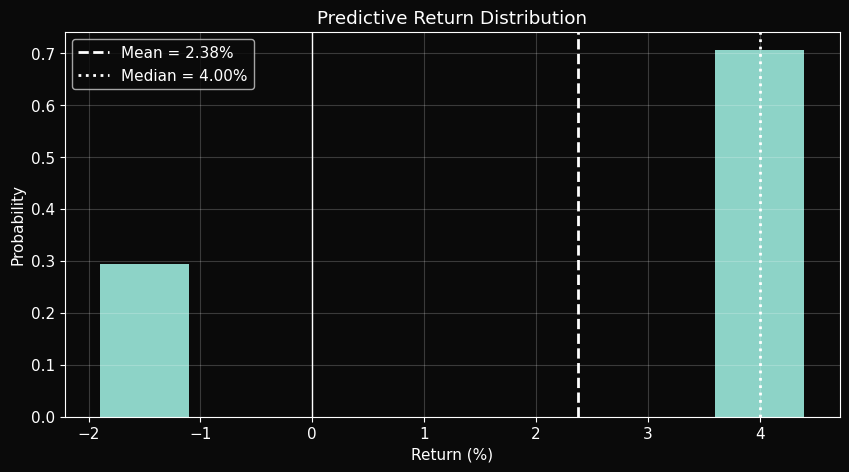

In [360]:
def plot_return_distribution(
    return_draws,
    title='Predictive Return Distribution',
):
    '''
    Plot either a discrete or continuous predictive
    return distribution.
    '''

    returns = np.asarray(
        return_draws,
        dtype=float,
    )

    unique_values = np.unique(
        returns
    )

    mean_return = returns.mean()
    median_return = np.median(returns)

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    # --------------------------------------------------------
    # Discrete distribution
    # --------------------------------------------------------

    if len(unique_values) <= 10:

        values, counts = np.unique(
            returns,
            return_counts=True,
        )

        probabilities = (
            counts / counts.sum()
        )

        ax.bar(
            values * 100,
            probabilities,
        )

        ax.set_ylabel(
            'Probability'
        )

    # --------------------------------------------------------
    # Continuous / richer distribution
    # --------------------------------------------------------

    else:

        ax.hist(
            returns * 100,
            bins='fd',
            alpha=0.7,
            edgecolor='black',
        )

        ax.set_ylabel(
            'Frequency'
        )

    # --------------------------------------------------------
    # Distribution center
    # --------------------------------------------------------

    ax.axvline(
        mean_return * 100,
        linestyle='--',
        linewidth=2,
        label=(
            f'Mean = '
            f'{mean_return:.2%}'
        ),
    )

    ax.axvline(
        median_return * 100,
        linestyle=':',
        linewidth=2,
        label=(
            f'Median = '
            f'{median_return:.2%}'
        ),
    )

    ax.axvline(
        0,
        linewidth=1,
    )

    ax.set_xlabel(
        'Return (%)'
    )

    ax.set_title(
        title
    )

    ax.legend()

    plt.show()

plot_return_distribution(
    return_draws
)


## 3. Transaction Costs and Liquidity

The predictive return distribution describes the investment opportunity before implementation costs.

If the position is:

$$
q\in\mathbb R,
$$

gross dollar P&L is:

$$
q\tilde R.
$$

A positive $q$ represents a long position and a negative $q$ a short position.

### 3.1 Proportional transaction costs

Let:

$$
c\geq0
$$

be the proportional round-trip trading cost.

Trading costs must be positive regardless of trade direction, so the dollar cost is:

$$
\boxed{
C_{\text{linear}}(q)
=
c|q|.
}
$$

This is why costs cannot simply be written as $cq$: if $q<0$, that expression would incorrectly imply a negative trading cost.

Therefore P&L after proportional costs, but before market impact, is:

$$
q\tilde R-c|q|.
$$

For a long position:

$$
q>0
\quad\Rightarrow\quad
q\tilde R-cq,
$$

while for a short position:

$$
q<0
\quad\Rightarrow\quad
q\tilde R-c(-q).
$$

The same framework can later allow different long and short costs, for example to include stock-borrow costs on short positions.

---

### 3.2 Market impact

Large trades can move the execution price against the investor.

Let:

$$
V>0
$$

denote average daily dollar volume and define absolute market participation as:

$$
z=\frac{|q|}{V}.
$$

Assume that marginal impact cost increases linearly with participation:

$$
\frac{dI(s)}{ds}
=
\eta\frac{s}{V},
\qquad
s=|q|,
$$

where $\eta>0$ measures how quickly execution becomes more expensive as trade size increases.

Total market-impact cost is obtained by integrating marginal cost:

$$
I(q)
=
\int_0^{|q|}
\eta\frac{x}{V}\,dx.
$$

Therefore:

$$
I(q)
=
\frac{\eta}{V}
\frac{|q|^2}{2}.
$$

Because:

$$
|q|^2=q^2,
$$

we obtain:

$$
\boxed{
I(q)
=
\frac{\eta}{2V}q^2.
}
$$

Define:

$$
\kappa
=
\frac{\eta}{V}.
$$

Then:

$$
\boxed{
I(q)
=
\frac12\kappa q^2.
}
$$

The two implementation costs therefore have different shapes:

$$
\boxed{
C(q)
=
c|q|
+
\frac12\kappa q^2.
}
$$

The first term is proportional to trade size. The second is convex: large positions become increasingly expensive relative to available liquidity.

The quadratic impact model is a stylized local approximation. Its functional form follows from the assumption of linearly increasing marginal impact; the parameter $\eta$ must eventually be estimated or calibrated from market data.


In [361]:
def prepare_trade_inputs(
    return_draws,
    cost_draws,
    liquidity_draws,
):
    '''
    Validate and summarize predictive returns,
    proportional trading costs and liquidity inputs.

    Costs are kept separate from returns because
    proportional cost depends on |q|, not on q.
    '''

    returns = np.asarray(
        return_draws,
        dtype=float,
    )

    liquidity = np.asarray(
        liquidity_draws,
        dtype=float,
    )

    linear_costs = np.asarray(
        cost_draws['linear_cost_rate'],
        dtype=float,
    )

    impact_slopes = np.asarray(
        cost_draws['impact_slope'],
        dtype=float,
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if returns.ndim != 1:
        raise ValueError(
            'return_draws must be one-dimensional.'
        )

    if liquidity.ndim != 1:
        raise ValueError(
            'liquidity_draws must be one-dimensional.'
        )

    if len(returns) < 2:
        raise ValueError(
            'At least two return draws are required.'
        )

    if len(linear_costs) != len(impact_slopes):
        raise ValueError(
            'linear cost and impact-slope draws must '
            'have the same length.'
        )

    if len(impact_slopes) != len(liquidity):
        raise ValueError(
            'impact-slope and liquidity draws must '
            'have the same length.'
        )

    if not np.isfinite(returns).all():
        raise ValueError(
            'return_draws contain NaN or infinite values.'
        )

    if not np.isfinite(linear_costs).all():
        raise ValueError(
            'linear cost draws contain NaN or infinite values.'
        )

    if not np.isfinite(impact_slopes).all():
        raise ValueError(
            'impact-slope draws contain NaN or infinite values.'
        )

    if not np.isfinite(liquidity).all():
        raise ValueError(
            'liquidity draws contain NaN or infinite values.'
        )

    if np.any(linear_costs < 0):
        raise ValueError(
            'Linear transaction costs cannot be negative.'
        )

    if np.any(impact_slopes <= 0):
        raise ValueError(
            'Impact slopes must be positive.'
        )

    if np.any(liquidity <= 0):
        raise ValueError(
            'Liquidity draws must be positive.'
        )


    # --------------------------------------------------------
    # Liquidity-adjusted impact coefficient
    # --------------------------------------------------------

    impact_coefficient_draws = (
        impact_slopes
        / liquidity
    )


    return {
        'return_draws': returns,

        'mean_return':
            returns.mean(),

        'return_variance':
            returns.var(ddof=1),

        'return_std':
            returns.std(ddof=1),

        'mean_linear_cost_rate':
            linear_costs.mean(),

        'linear_cost_draws':
            linear_costs,

        'mean_impact_coefficient':
            impact_coefficient_draws.mean(),

        'impact_coefficient_draws':
            impact_coefficient_draws,

        'mean_adv_usd':
            liquidity.mean(),
    }


In [362]:
# ============================================================
# EDUCATIONAL MARKET INPUTS
# Synthetic values only — not empirical estimates.
# ============================================================

cost_draws = pd.DataFrame(
    {
        'linear_cost_rate':
            np.full(
                N_DRAWS,
                0.0015,
            ),

        'impact_slope':
            np.full(
                N_DRAWS,
                0.20,
            ),
    }
)


liquidity_draws = np.full(
    N_DRAWS,
    100_000_000.0,
)


trade_inputs = prepare_trade_inputs(
    return_draws=return_draws,
    cost_draws=cost_draws,
    liquidity_draws=liquidity_draws,
)


trade_input_summary = pd.Series({
    'Mean gross return':
        trade_inputs['mean_return'],

    'Return standard deviation':
        trade_inputs['return_std'],

    'Mean linear cost rate':
        trade_inputs['mean_linear_cost_rate'],

    'Mean impact coefficient':
        trade_inputs['mean_impact_coefficient'],

    'Mean ADV ($)':
        trade_inputs['mean_adv_usd'],
})


display(trade_input_summary)


Mean gross return                     0.0238
Return standard deviation             0.0251
Mean linear cost rate                 0.0015
Mean impact coefficient               0.0000
Mean ADV ($)                100,000,000.0000
dtype: float64

In [363]:
def linear_transaction_cost(
    q,
    cost_rate,
):
    '''
    Proportional dollar transaction cost.
    Positive for both long and short trades.
    '''

    if cost_rate < 0:
        raise ValueError(
            'cost_rate cannot be negative.'
        )

    return (
        cost_rate
        * np.abs(q)
    )


def market_impact_cost(
    q,
    impact_slope,
    adv_usd,
):
    '''
    Quadratic market-impact cost implied by
    linearly increasing marginal impact.
    '''

    if impact_slope <= 0:
        raise ValueError(
            'impact_slope must be positive.'
        )

    if adv_usd <= 0:
        raise ValueError(
            'adv_usd must be positive.'
        )

    return (
        0.5
        * impact_slope
        * q**2
        / adv_usd
    )


def total_implementation_cost(
    q,
    cost_rate,
    impact_slope,
    adv_usd,
):
    '''
    Total implementation cost:
    proportional cost + nonlinear market impact.
    '''

    return (
        linear_transaction_cost(
            q,
            cost_rate,
        )
        +
        market_impact_cost(
            q,
            impact_slope,
            adv_usd,
        )
    )


In [364]:
# ------------------------------------------------------------
# Implementation-cost consistency checks
# ------------------------------------------------------------

Q_TEST = 5_000_000
C_TEST = 0.0015
ETA_TEST = 0.20
ADV_TEST = 100_000_000


# Zero position must have zero implementation cost
assert np.isclose(
    total_implementation_cost(
        0,
        C_TEST,
        ETA_TEST,
        ADV_TEST,
    ),
    0.0,
)


# Long and short positions of equal size
# should have the same symmetric implementation cost
assert np.isclose(
    total_implementation_cost(
        Q_TEST,
        C_TEST,
        ETA_TEST,
        ADV_TEST,
    ),
    total_implementation_cost(
        -Q_TEST,
        C_TEST,
        ETA_TEST,
        ADV_TEST,
    ),
)


# Linear cost doubles when trade size doubles
assert np.isclose(
    linear_transaction_cost(
        2 * Q_TEST,
        C_TEST,
    ),
    2
    * linear_transaction_cost(
        Q_TEST,
        C_TEST,
    ),
)


# Quadratic impact quadruples when trade size doubles
assert np.isclose(
    market_impact_cost(
        2 * Q_TEST,
        ETA_TEST,
        ADV_TEST,
    ),
    4
    * market_impact_cost(
        Q_TEST,
        ETA_TEST,
        ADV_TEST,
    ),
)


print(
    'Implementation-cost checks passed.'
)


Implementation-cost checks passed.


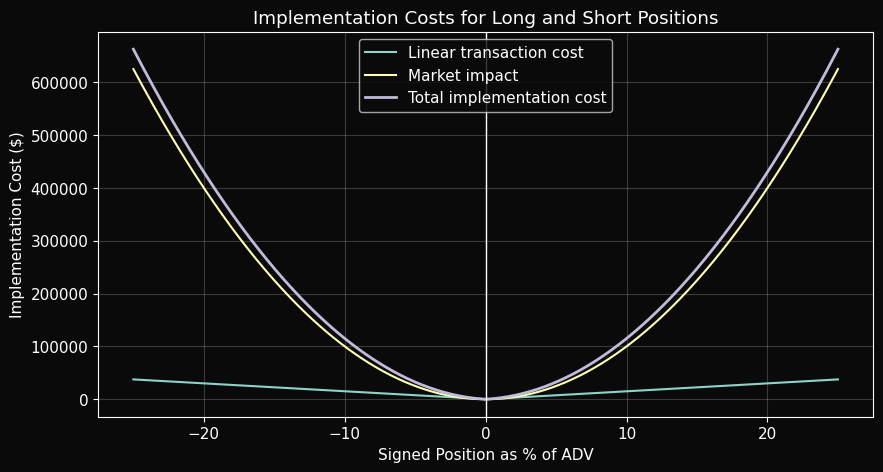

In [365]:
q_grid = np.linspace(
    -0.25 * ADV_TEST,
    0.25 * ADV_TEST,
    500,
)


linear_cost_grid = (
    linear_transaction_cost(
        q_grid,
        C_TEST,
    )
)


impact_cost_grid = (
    market_impact_cost(
        q_grid,
        ETA_TEST,
        ADV_TEST,
    )
)


total_cost_grid = (
    linear_cost_grid
    +
    impact_cost_grid
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)


ax.plot(
    q_grid / ADV_TEST * 100,
    linear_cost_grid,
    label='Linear transaction cost',
)


ax.plot(
    q_grid / ADV_TEST * 100,
    impact_cost_grid,
    label='Market impact',
)


ax.plot(
    q_grid / ADV_TEST * 100,
    total_cost_grid,
    linewidth=2,
    label='Total implementation cost',
)


ax.axvline(
    0,
    linewidth=1,
)


ax.set_xlabel(
    'Signed Position as % of ADV'
)

ax.set_ylabel(
    'Implementation Cost ($)'
)

ax.set_title(
    'Implementation Costs for Long and Short Positions'
)

ax.legend()

plt.show()


In [366]:
def horizon_adjusted_impact_coefficient(
    one_day_impact_coefficient,
    execution_days,
):
    '''
    Effective impact curvature when a trade is
    executed evenly over H trading days.
    '''

    if one_day_impact_coefficient <= 0:
        raise ValueError(
            'one_day_impact_coefficient must be positive.'
        )

    if execution_days <= 0:
        raise ValueError(
            'execution_days must be positive.'
        )

    return (
        one_day_impact_coefficient
        / execution_days
    )


## 4. Risk-Adjusted Optimal Position

A trade should not be evaluated only through expected P&L, two trades can have the same expected return while having very different downside uncertainty. To account for this difference, the investor is assumed to care about expected utility of terminal wealth.

---

### 4.1 Expected utility

Let current portfolio wealth be:

$$
W
$$

and let:

$$
X(q)
$$

be the uncertain dollar P&L generated by a position of size $q$.

Terminal wealth is:

$$
W+X(q).
$$

The investor evaluates the position through:

$$
\boxed{
\mathbb E[U(W+X(q))]
}
$$

where risk aversion means:

$$
U'(W)>0
$$

and:

$$
U''(W)<0.
$$

The first condition means that more wealth is preferred, the second means that utility is concave: an additional dollar provides less additional utility when wealth is already high.

---

### 4.2 Taylor approximation around expected terminal wealth

Define:

$$
m
=
W+\mathbb E[X].
$$

Write the random P&L as:

$$
X
=
\mathbb E[X]+\varepsilon
$$

where:

$$
\mathbb E[\varepsilon]=0.
$$

Therefore:

$$
W+X=m+\varepsilon.
$$

A second-order Taylor approximation of utility around $m$ is:

$$
U(m+\varepsilon)
\approx
U(m)
+
U'(m)\varepsilon
+
\frac12U''(m)\varepsilon^2.
$$

Taking expectations:

$$
\mathbb E[U(m+\varepsilon)]
\approx
U(m)
+
U'(m)\mathbb E[\varepsilon]
+
\frac12U''(m)\mathbb E[\varepsilon^2].
$$

Because:

$$
\mathbb E[\varepsilon]=0,
$$

the first-order random term disappears.

Also:

$$
\mathbb E[\varepsilon^2]
=
\operatorname{Var}(X).
$$

Therefore:

$$
\boxed{
\mathbb E[U(W+X)]
\approx
U(m)
+
\frac12U''(m)\operatorname{Var}(X).
}
$$

Since:

$$
U''(m)<0,
$$

greater uncertainty reduces expected utility.

---

### 4.3 Certainty equivalent

The certainty equivalent is the certain P&L that makes the investor indifferent between receiving that amount with certainty and taking the risky trade.

It is defined by:

$$
\boxed{
U(W+CE)
=
\mathbb E[U(W+X)].
}
$$

For a sufficiently small risky payoff relative to wealth, another local Taylor approximation gives:

$$
U(W+CE)
\approx
U(m)
+
U'(m)
\left(
CE-\mathbb E[X]
\right).
$$

Equating this expression with the previous expected-utility approximation gives:

$$
U'(m)
\left(
CE-\mathbb E[X]
\right)
\approx
\frac12
U''(m)
\operatorname{Var}(X).
$$

Hence:

$$
CE
\approx
\mathbb E[X]
+
\frac12
\frac{U''(m)}{U'(m)}
\operatorname{Var}(X).
$$

Define absolute risk aversion:

$$
\boxed{
A(m)
=
-\frac{U''(m)}{U'(m)}.
}
$$

Then:

$$
\boxed{
CE
\approx
\mathbb E[X]
-
\frac12
A(m)
\operatorname{Var}(X).
}
$$

This is the origin of the mean-variance risk penalty.

---

### 4.4 CRRA risk preferences

To obtain an interpretable risk-aversion coefficient, consider constant-relative-risk-aversion utility:

$$
U(W)
=
\frac{W^{1-\rho}}{1-\rho},
\qquad
\rho>0.
$$

Its derivatives are:

$$
U'(W)=W^{-\rho}
$$

and:

$$
U''(W)
=
-\rho W^{-\rho-1}.
$$

Therefore:

$$
A(W)
=
-\frac{U''(W)}{U'(W)}
=
\boxed{
\frac{\rho}{W}.
}
$$

When the trade is small relative to total portfolio wealth:

$$
m
=
W+\mathbb E[X]
\approx
W,
$$

so:

$$
A(m)
\approx
\frac{\rho}{W}.
$$

The certainty equivalent becomes:

$$
\boxed{
CE
\approx
\mathbb E[X]
-
\frac{\rho}{2W}
\operatorname{Var}(X).
}
$$

---

### 4.5 Apply the certainty equivalent to a signed position

From the previous derivation, the approximate certainty-equivalent objective is:

$$
CE(q)
\approx
\mathbb E[X(q)]
-
\frac{\rho}{2W}
\operatorname{Var}(X(q)).
$$

For a signed dollar position:

$$
q\in\mathbb R,
$$

trade P&L is:

$$
X(q)
=
q\tilde R
-
c|q|
-
\frac12\kappa q^2.
$$

The first term is the uncertain investment payoff. The other two terms are implementation costs.

Because the cost terms are deterministic conditional on the current market estimates:

$$
\mathbb E[X(q)]
=
q\mu
-
c|q|
-
\frac12\kappa q^2,
$$

where:

$$
\mu=\mathbb E[\tilde R].
$$

The variance of P&L is:

$$
\operatorname{Var}(X(q))
=
q^2\sigma^2,
$$

because:

$$
\operatorname{Var}(q\tilde R)
=
q^2\operatorname{Var}(\tilde R).
$$

Substituting into the certainty equivalent gives:

$$
\boxed{
J(q)
=
q\mu
-
c|q|
-
\frac12
\left(
\kappa
+
\frac{\rho}{W}\sigma^2
\right)q^2.
}
$$

Define:

$$
\lambda
=
\kappa
+
\frac{\rho}{W}\sigma^2.
$$

Then:

$$
J(q)
=
q\mu
-
c|q|
-
\frac12\lambda q^2.
$$

---

### 4.6 Long, short or no trade

Because of the absolute value $|q|$, the objective is solved separately for long and short positions.

For a long position, $q>0$, so:

$$
|q|=q.
$$

Therefore:

$$
J(q)
=
q(\mu-c)
-
\frac12\lambda q^2.
$$

The long position has positive expected economic edge only if:

$$
\mu>c.
$$

Its unconstrained optimum is:

$$
q_{\text{long}}
=
\frac{\mu-c}{\lambda}.
$$

For a short position, $q<0$, so:

$$
|q|=-q.
$$

Therefore:

$$
J(q)
=
q(\mu+c)
-
\frac12\lambda q^2.
$$

The optimal position is short when:

$$
\mu<-c,
$$

with:

$$
q_{\text{short}}
=
\frac{\mu+c}{\lambda}<0.
$$

If:

$$
-c\leq\mu\leq c,
$$

the expected return is not large enough in either direction to overcome proportional transaction costs.

The optimal decision is therefore:

$$
q^*=0.
$$

The three cases can be written compactly as:

$$
\boxed{
q_{\text{risk}}
=
\frac{
\operatorname{sign}(\mu)
\max(|\mu|-c,0)
}{
\kappa+(\rho/W)\sigma^2
}.
}
$$

This formula allows the optimizer to determine both trade direction and position size.

A positive result implies a long position, a negative result a short position, and zero implies no trade.


---
### 4.7 Tail-loss constraint

A loss constraint based on the single worst simulated return can be unstable because the observed minimum becomes more extreme as the number of predictive draws increases.

Instead, the model uses the lower-tail **Expected Shortfall** of the directional return distribution.

Let:

$$
d=
\begin{cases}
+1, & \text{long},\\
-1, & \text{short},
\end{cases}
$$

and let:

$$
s=|q|.
$$

For predictive return draw $r_i$, the directional return after proportional trading cost is:

$$
z_i
=
dr_i-c.
$$

Choose a tail probability:

$$
0<\alpha<1.
$$

Let:

$$
Q_\alpha(Z)
$$

be the lower $\alpha$-quantile of the directional return distribution.

Lower-tail Expected Shortfall is:

$$
\boxed{
ES_\alpha(Z)
=
\mathbb E[
Z
\mid
Z\leq Q_\alpha(Z)
].
}
$$

It represents the average return in the adverse tail rather than relying on one extreme observation.

For position magnitude $s$, tail P&L is approximately:

$$
ES_\alpha(X)
=
s\,ES_\alpha(Z)
-
\frac12\kappa s^2.
$$

If the investor's maximum tolerated tail loss is:

$$
L>0,
$$

require:

$$
ES_\alpha(X)
\geq
-L.
$$

At the binding boundary:

$$
\frac12\kappa s^2
-
ES_\alpha(Z)s
-
L
=
0.
$$

Therefore:

$$
\boxed{
s_{\text{loss}}
=
\frac{
ES_\alpha(Z)
+
\sqrt{
ES_\alpha(Z)^2+2\kappa L
}
}{
\kappa
}.
}
$$

The tail probability $\alpha$ is an investor-policy choice, not an estimated market parameter. A smaller $\alpha$ focuses the constraint on more extreme outcomes.

---

### 4.8 Daily liquidity-capacity constraint

Suppose the investor allows at most a fraction:

$$
\phi
$$

of average daily dollar volume to be traded each day.

If execution can occur over:

$$
H
$$

trading days and estimated daily dollar volume is:

$$
\bar V,
$$

then daily trade capacity is:

$$
\phi\bar V.
$$

Over $H$ days:

$$
\boxed{
q_{\text{capacity}}
=
\phi H\bar V.
}
$$

The final feasible position is:

$$
\boxed{
q^*
=
\operatorname{sign(q_{\text{risk}})}
\min
\left(
|q_{\text{risk}}|,
q_{\text{loss}},
q_{\text{capacity}}
\right).
}
$$

The optimizer therefore reports both the position and the constraint responsible for limiting it.


In [367]:
def risk_adjusted_position(
    mean_return,
    return_variance,
    linear_cost_rate,
    impact_coefficient,
    portfolio_value,
    risk_aversion,
):
    '''
    Unconstrained optimal signed dollar position.

    Positive q -> long
    Negative q -> short
    Zero q     -> no trade
    '''

    if portfolio_value <= 0:
        raise ValueError(
            'portfolio_value must be positive.'
        )

    if risk_aversion < 0:
        raise ValueError(
            'risk_aversion cannot be negative.'
        )

    if linear_cost_rate < 0:
        raise ValueError(
            'linear_cost_rate cannot be negative.'
        )

    if impact_coefficient <= 0:
        raise ValueError(
            'impact_coefficient must be positive.'
        )

    if return_variance < 0:
        raise ValueError(
            'return_variance cannot be negative.'
        )


    # Total curvature from liquidity + risk
    curvature = (
        impact_coefficient
        +
        (risk_aversion / portfolio_value)
        * return_variance
    )


    # Expected return must first overcome
    # proportional trading costs.
    economic_edge = max(
        abs(mean_return)
        - linear_cost_rate,
        0.0,
    )


    if economic_edge == 0:
        q_risk = 0.0

    else:
        direction = np.sign(
            mean_return
        )

        q_risk = (
            direction
            * economic_edge
            / curvature
        )


    return {
        'q_risk_usd': q_risk,
        'direction':
            (
                'long'
                if q_risk > 0
                else 'short'
                if q_risk < 0
                else 'no_trade'
            ),

        'gross_mean_return':
            mean_return,

        'economic_edge':
            economic_edge,

        'curvature':
            curvature,

        'impact_curvature':
            impact_coefficient,

        'risk_curvature':
            (
                risk_aversion
                / portfolio_value
                * return_variance
            ),
    }

def optimize_position(
    return_draws,
    cost_draws,
    liquidity_draws,
    portfolio_value,
    risk_aversion,
    loss_budget,
    *,
    tail_probability,
    max_participation,
    execution_days,
):
    '''
    Optimize a signed dollar position under:

    - predictive return uncertainty;
    - proportional transaction costs;
    - quadratic market impact;
    - risk aversion;
    - maximum-loss constraint;
    - trading-capacity constraint.

    Positive q* -> long
    Negative q* -> short
    Zero q*     -> no trade
    '''

    # --------------------------------------------------------
    # Investor-policy validation
    # --------------------------------------------------------

    if portfolio_value <= 0:
        raise ValueError(
            'portfolio_value must be positive.'
        )

    if risk_aversion < 0:
        raise ValueError(
            'risk_aversion cannot be negative.'
        )

    if loss_budget <= 0:
        raise ValueError(
            'loss_budget must be positive.'
        )

    if not 0 < max_participation <= 1:
        raise ValueError(
            'max_participation must lie in (0, 1].'
        )

    if execution_days <= 0:
        raise ValueError(
            'execution_days must be positive.'
        )

    if not 0 < tail_probability < 1:
        raise ValueError(
            'tail probability must be between 0 and 1'
        )


    # --------------------------------------------------------
    # Prepare model and market inputs
    # --------------------------------------------------------

    inputs = prepare_trade_inputs(
        return_draws=return_draws,
        cost_draws=cost_draws,
        liquidity_draws=liquidity_draws,
    )

    returns = inputs['return_draws']

    mu = inputs['mean_return']

    variance = inputs[
        'return_variance'
    ]

    cost_rate = inputs[
        'mean_linear_cost_rate'
    ]

    kappa_one_day = inputs[
        'mean_impact_coefficient'
    ]

    kappa = horizon_adjusted_impact_coefficient(
        one_day_impact_coefficient=kappa_one_day,
        execution_days=execution_days,
    )

    adv = inputs[
        'mean_adv_usd'
    ]


    # --------------------------------------------------------
    # 1. Desired risk-adjusted signed position
    # --------------------------------------------------------

    risk_result = risk_adjusted_position(
        mean_return=mu,
        return_variance=variance,
        linear_cost_rate=cost_rate,
        impact_coefficient=kappa,
        portfolio_value=portfolio_value,
        risk_aversion=risk_aversion,
    )

    q_risk = (
        risk_result['q_risk_usd']
    )


    # --------------------------------------------------------
    # No-trade region
    # --------------------------------------------------------

    if np.isclose(q_risk, 0.0):

        return {
            'q_star_usd': 0.0,
            'q_risk_usd': 0.0,
            'q_loss_abs_usd': np.inf,
            'q_capacity_abs_usd':
                (
                    max_participation
                    * execution_days
                    * adv
                ),
            'direction': 'no_trade',
            'binding_constraint': 'no_trade',
            'portfolio_weight': 0.0,
            'adv_fraction': 0.0,
            'daily_adv_participation': 0.0,
            'one_day_impact_coefficient': kappa_one_day,
            'effective_impact_coefficient': kappa,
            'expected_pnl_usd': 0.0,
            'pnl_std_usd': 0.0,
            'worst_draw_pnl_usd': 0.0,
            'tail_expected_shortfall': np.nan,
            'tail_quantile': np.nan,
            'pnl_draws':
                np.zeros_like(returns),
        }


    # --------------------------------------------------------
    # Direction implied by the optimizer
    # --------------------------------------------------------

    direction = int(
        np.sign(q_risk)
    )


    # --------------------------------------------------------
    # 2. Directional loss constraint
    # --------------------------------------------------------

    loss_result = directional_loss_limit(
    return_draws=returns,
    direction=direction,
    linear_cost_rate=cost_rate,
    impact_coefficient=kappa,
    loss_budget=loss_budget,
    tail_probability=tail_probability,
    )

    q_loss_abs = (
        loss_result['q_loss_abs_usd']
    )


    # --------------------------------------------------------
    # 3. Absolute trading-capacity constraint
    # --------------------------------------------------------

    q_capacity_abs = (
        max_participation
        * execution_days
        * adv
    )


    # --------------------------------------------------------
    # 4. Final feasible position magnitude
    # --------------------------------------------------------

    candidate_magnitudes = {
        'risk_adjusted':
            abs(q_risk),

        'loss_budget':
            q_loss_abs,

        'daily_capacity':
            q_capacity_abs,
    }


    q_star_abs = min(
        candidate_magnitudes.values()
    )


    binding_constraint = min(
        candidate_magnitudes,
        key=candidate_magnitudes.get,
    )


    # Restore trade direction
    q_star = (
        direction
        * q_star_abs
    )


    # --------------------------------------------------------
    # 5. P&L distribution at final position
    # --------------------------------------------------------

    pnl_draws = (
        q_star * returns
        -
        cost_rate * abs(q_star)
        -
        0.5 * kappa * q_star**2
    )


    return {
        'q_star_usd':
            q_star,

        'q_risk_usd':
            q_risk,

        'q_loss_abs_usd':
            q_loss_abs,

        'q_capacity_abs_usd':
            q_capacity_abs,

        'direction':
            (
                'long'
                if q_star > 0
                else 'short'
            ),

        'binding_constraint':
            binding_constraint,

        'portfolio_weight':
            q_star / portfolio_value,

        'adv_fraction':
            abs(q_star) / adv,

        'daily_adv_participation':
            abs(q_star) / (execution_days * adv),

        'one_day_impact_coefficient':
            kappa_one_day,

        'effective_impact_coefficient':
            kappa,

        'expected_pnl_usd':
            pnl_draws.mean(),

        'pnl_std_usd':
            pnl_draws.std(ddof=1),

        'worst_draw_pnl_usd':
            pnl_draws.min(),

        'pnl_draws':
            pnl_draws,

        'tail_expected_shortfall':
            loss_result['tail_expected_shortfall'],

        'tail_quantile':
            loss_result['tail_quantile'],
    }


In [368]:
# ============================================================
# SIGNED-POSITION CONSISTENCY TESTS
# ============================================================

TEST_VARIANCE = 0.0006
TEST_COST = 0.0015
TEST_KAPPA = 2e-9
TEST_W = 50_000_000
TEST_RHO = 4.0


long_test = risk_adjusted_position(
    mean_return=0.03,
    return_variance=TEST_VARIANCE,
    linear_cost_rate=TEST_COST,
    impact_coefficient=TEST_KAPPA,
    portfolio_value=TEST_W,
    risk_aversion=TEST_RHO,
)


short_test = risk_adjusted_position(
    mean_return=-0.03,
    return_variance=TEST_VARIANCE,
    linear_cost_rate=TEST_COST,
    impact_coefficient=TEST_KAPPA,
    portfolio_value=TEST_W,
    risk_aversion=TEST_RHO,
)


no_trade_test = risk_adjusted_position(
    mean_return=0.001,
    return_variance=TEST_VARIANCE,
    linear_cost_rate=TEST_COST,
    impact_coefficient=TEST_KAPPA,
    portfolio_value=TEST_W,
    risk_aversion=TEST_RHO,
)


assert long_test['q_risk_usd'] > 0

assert short_test['q_risk_usd'] < 0

assert np.isclose(
    abs(long_test['q_risk_usd']),
    abs(short_test['q_risk_usd']),
)

assert np.isclose(
    no_trade_test['q_risk_usd'],
    0.0,
)


print(
    'Signed-position checks passed.'
)


Signed-position checks passed.


In [369]:
def empirical_lower_expected_shortfall(
    values,
    tail_probability,
):
    '''
    Empirical lower-tail Expected Shortfall.

    Returns the average of the worst alpha fraction
    of observations, using fractional weighting when
    alpha * N is not an integer.
    '''

    values = np.asarray(
        values,
        dtype=float,
    )

    if values.ndim != 1:
        raise ValueError(
            'values must be one-dimensional.'
        )

    if len(values) < 2:
        raise ValueError(
            'At least two observations are required.'
        )

    if not 0 < tail_probability < 1:
        raise ValueError(
            'tail_probability must lie in (0, 1).'
        )


    sorted_values = np.sort(
        values
    )


    n = len(sorted_values)

    tail_mass = (
        tail_probability * n
    )


    n_full = int(
        np.floor(tail_mass)
    )

    fractional_weight = (
        tail_mass - n_full
    )


    tail_sum = (
        sorted_values[:n_full].sum()
    )


    if fractional_weight > 0:

        tail_sum += (
            fractional_weight
            * sorted_values[n_full]
        )


    expected_shortfall = (
        tail_sum / tail_mass
    )


    tail_quantile = np.quantile(
        sorted_values,
        tail_probability,
    )


    return {
        'tail_quantile':
            tail_quantile,

        'expected_shortfall':
            expected_shortfall,
    }


In [370]:
def directional_loss_limit(
    return_draws,
    direction,
    linear_cost_rate,
    impact_coefficient,
    loss_budget,
    tail_probability,
):
    '''
    Maximum absolute position consistent with
    a lower-tail Expected Shortfall loss budget.

    direction = +1 -> long
    direction = -1 -> short
    '''

    returns = np.asarray(
        return_draws,
        dtype=float,
    )


    if direction not in (-1, 1):
        raise ValueError(
            'direction must be +1 or -1.'
        )

    if linear_cost_rate < 0:
        raise ValueError(
            'linear_cost_rate cannot be negative.'
        )

    if impact_coefficient <= 0:
        raise ValueError(
            'impact_coefficient must be positive.'
        )

    if loss_budget <= 0:
        raise ValueError(
            'loss_budget must be positive.'
        )

    if not 0 < tail_probability < 1:
        raise ValueError(
            'tail_probability must lie in (0, 1).'
        )


    # Directional return per dollar of absolute exposure
    directional_net_returns = (
        direction * returns
        - linear_cost_rate
    )


    tail_result = (
        empirical_lower_expected_shortfall(
            directional_net_returns,
            tail_probability,
        )
    )


    tail_es = (
        tail_result[
            'expected_shortfall'
        ]
    )


    q_loss_abs = (
        tail_es
        +
        np.sqrt(
            tail_es**2
            +
            2
            * impact_coefficient
            * loss_budget
        )
    ) / impact_coefficient


    return {
        'q_loss_abs_usd':
            q_loss_abs,

        'tail_expected_shortfall':
            tail_es,

        'tail_quantile':
            tail_result[
                'tail_quantile'
            ],
    }


In [371]:
# ============================================================
# EDUCATIONAL INVESTOR-POLICY INPUTS
# Synthetic values only.
# ============================================================

portfolio_value = 50_000_000
risk_aversion = 4.0
loss_budget = 500_000

# Tail probability is an investor-policy input.
# 5% is used only for the educational example.
tail_probability = 0.05

max_participation = 0.10
execution_days = 10


In [372]:
position_result = optimize_position(
    return_draws=return_draws,
    cost_draws=cost_draws,
    liquidity_draws=liquidity_draws,
    portfolio_value=portfolio_value,
    risk_aversion=risk_aversion,
    loss_budget=loss_budget,
    max_participation=max_participation,
    tail_probability=tail_probability,
    execution_days=execution_days,
)


position_summary = pd.Series({
    key: value
    for key, value
    in position_result.items()
    if key != 'pnl_draws'
})


display(
    position_summary
)


q_star_usd                      26,156,569.0605
q_risk_usd                      89,132,034.1605
q_loss_abs_usd                  26,156,569.0605
q_capacity_abs_usd             100,000,000.0000
direction                                  long
binding_constraint                  loss_budget
portfolio_weight                         0.5231
adv_fraction                             0.2616
daily_adv_participation                  0.0262
one_day_impact_coefficient               0.0000
effective_impact_coefficient             0.0000
expected_pnl_usd                   515,084.1321
pnl_std_usd                        655,745.1535
worst_draw_pnl_usd                -500,000.0000
tail_expected_shortfall                 -0.0165
tail_quantile                           -0.0165
dtype: object

In [373]:
# ============================================================
# EXPECTED-SHORTFALL LOSS-CONSTRAINT CHECK
# ============================================================

tail_result = empirical_lower_expected_shortfall(
    position_result['pnl_draws'],
    tail_probability,
)

pnl_expected_shortfall = (
    tail_result[
        'expected_shortfall'
    ]
)

assert (
    pnl_expected_shortfall
    >= -loss_budget - 1e-6
)

print(
    'Expected-Shortfall loss constraint passed.'
)


Expected-Shortfall loss constraint passed.


In [374]:
# ============================================================
# SHORT-POSITION SOFTWARE TEST
#
# Mirror the educational return distribution.
# This tests symmetry only; it is not an empirical scenario.
# ============================================================

negative_return_draws = (
    -return_draws
)


short_position_result = optimize_position(
    return_draws=negative_return_draws,
    cost_draws=cost_draws,
    liquidity_draws=liquidity_draws,
    portfolio_value=portfolio_value,
    risk_aversion=risk_aversion,
    loss_budget=loss_budget,
    max_participation=max_participation,
    tail_probability=tail_probability,
    execution_days=execution_days,
)


assert (
    short_position_result['q_star_usd']
    < 0
)

assert (
    short_position_result['direction']
    == 'short'
)


print(
    'Full short-position optimization check passed.'
)


Full short-position optimization check passed.


In [375]:
assert np.isclose(
    abs(
        position_result[
            'q_risk_usd'
        ]
    ),
    abs(
        short_position_result[
            'q_risk_usd'
        ]
    ),
)


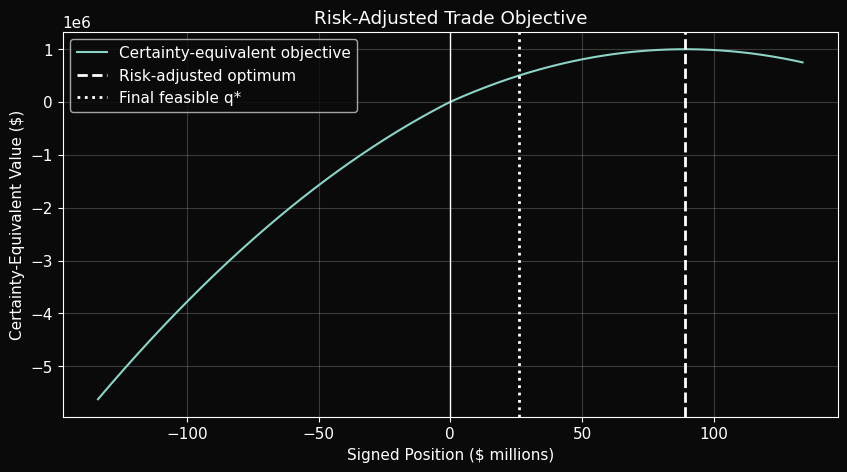

Trade direction: long
Binding constraint: loss_budget
Final position: $26.16m


In [376]:
mu = trade_inputs[
    'mean_return'
]

variance = trade_inputs[
    'return_variance'
]

cost_rate = trade_inputs[
    'mean_linear_cost_rate'
]

# Use exactly the horizon-adjusted impact coefficient
# used by the optimizer.
kappa = position_result[
    'effective_impact_coefficient'
]


q_scale = max(
    abs(
        position_result[
            'q_risk_usd'
        ]
    ),
    1_000_000,
)


q_grid = np.linspace(
    -1.5 * q_scale,
    1.5 * q_scale,
    600,
)


objective_grid = (
    q_grid * mu
    - cost_rate * np.abs(q_grid)
    - 0.5
    * kappa
    * q_grid**2
    - 0.5
    * (risk_aversion / portfolio_value)
    * variance
    * q_grid**2
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)


ax.plot(
    q_grid / 1_000_000,
    objective_grid,
    label='Certainty-equivalent objective',
)


# Zero separates short and long positions
ax.axvline(
    0,
    linewidth=1,
)


q_risk = position_result[
    'q_risk_usd'
]

q_star = position_result[
    'q_star_usd'
]


ax.axvline(
    q_risk / 1_000_000,
    linestyle='--',
    linewidth=2,
    label='Risk-adjusted optimum',
)


# Plot q* separately only when a hard constraint
# moves it away from the unconstrained optimum.
if not np.isclose(
    q_star,
    q_risk,
):

    ax.axvline(
        q_star / 1_000_000,
        linestyle=':',
        linewidth=2,
        label='Final feasible q*',
    )


ax.set_xlabel(
    'Signed Position ($ millions)'
)

ax.set_ylabel(
    'Certainty-Equivalent Value ($)'
)

ax.set_title(
    'Risk-Adjusted Trade Objective'
)

ax.legend()

plt.show()


print(
    f'Trade direction: '
    f'{position_result['direction']}'
)

print(
    f'Binding constraint: '
    f'{position_result['binding_constraint']}'
)

print(
    f'Final position: '
    f'${position_result['q_star_usd'] / 1_000_000:.2f}m'
)


## 5. Uncertainty in the Optimal Position

The optimizer in Section 4 produces one optimal position:

$$
q^*,
$$

conditional on the return, cost and liquidity distributions supplied to it.

However, these inputs are generally estimated rather than perfectly known.

Let:

$$
\theta
$$

represent the estimated model and market parameters.

The optimal position is therefore a function:

$$
q^*=g(\theta).
$$

If the data support several statistically plausible parameter states:

$$
\theta^{(1)},\theta^{(2)},\ldots,\theta^{(B)},
$$

each state generates its own predictive inputs and therefore its own optimal position:

$$
q^{*(b)}
=
g\left(\theta^{(b)}\right).
$$

The final output is therefore a distribution:

$$
\boxed{
q^{*(1)},q^{*(2)},\ldots,q^{*(B)}
}
$$

rather than one apparently precise position.

Because positions are signed, uncertainty can affect both **position size** and **trade direction**.

A batch may imply:

$$
q^{*(b)}>0
\quad\text{(long)},
$$

$$
q^{*(b)}<0
\quad\text{(short)},
$$

or:

$$
q^{*(b)}=0
\quad\text{(no trade)}.
$$

### Two different types of uncertainty

Predictive return draws describe uncertainty about what may happen in the future.

Parameter uncertainty describes uncertainty about the model used to generate that predictive distribution.

These are not the same thing.

In a final empirical application, the alternative input batches should therefore come from a statistically justified procedure such as repeated model estimation, a dependence-preserving bootstrap, or Bayesian posterior draws.

Investor-policy inputs such as risk aversion and the loss budget are kept fixed because they are choices, not unknown market parameters.


In [377]:
def optimize_position_distribution(
    return_draw_batches,
    cost_draw_batches,
    liquidity_draw_batches,
    portfolio_value,
    risk_aversion,
    loss_budget,
    *,
    tail_probability,
    max_participation,
    execution_days,
):
    '''
    Run the full signed-position optimizer across
    multiple statistically plausible input states.

    Each batch b produces one q*_b.
    '''

    n_batches = len(
        return_draw_batches
    )

    if n_batches == 0:
        raise ValueError(
            'At least one input batch is required.'
        )

    if len(cost_draw_batches) != n_batches:
        raise ValueError(
            'cost_draw_batches must have the same '
            'length as return_draw_batches.'
        )

    if len(liquidity_draw_batches) != n_batches:
        raise ValueError(
            'liquidity_draw_batches must have the same '
            'length as return_draw_batches.'
        )


    records = []


    for b in range(n_batches):

        result = optimize_position(
            return_draws=
                return_draw_batches[b],

            cost_draws=
                cost_draw_batches[b],

            liquidity_draws=
                liquidity_draw_batches[b],

            portfolio_value=
                portfolio_value,

            risk_aversion=
                risk_aversion,

            loss_budget=
                loss_budget,

            tail_probability=
                tail_probability,

            max_participation=
                max_participation,

            execution_days=
                execution_days,
        )


        records.append(
            {
                'batch':
                    b,

                'q_star_usd':
                    result['q_star_usd'],

                'q_star_abs_usd':
                    abs(result['q_star_usd']),

                'q_risk_usd':
                    result['q_risk_usd'],

                'q_loss_abs_usd':
                    result['q_loss_abs_usd'],

                'q_capacity_abs_usd':
                    result['q_capacity_abs_usd'],

                'direction':
                    result['direction'],

                'binding_constraint':
                    result['binding_constraint'],

                'expected_pnl_usd':
                    result['expected_pnl_usd'],

                'pnl_std_usd':
                    result['pnl_std_usd'],

                'worst_draw_pnl_usd':
                    result['worst_draw_pnl_usd'],
            }
        )


    return pd.DataFrame(
        records
    )


In [378]:
# ============================================================
# DISTRIBUTION-WRAPPER CONSISTENCY TEST
# Identical inputs must produce identical q* values.
# ============================================================

N_IDENTICAL_BATCHES = 20


identical_return_batches = [
    return_draws.copy()
    for _ in range(
        N_IDENTICAL_BATCHES
    )
]


identical_cost_batches = [
    cost_draws.copy()
    for _ in range(
        N_IDENTICAL_BATCHES
    )
]


identical_liquidity_batches = [
    liquidity_draws.copy()
    for _ in range(
        N_IDENTICAL_BATCHES
    )
]


identical_q_distribution = (
    optimize_position_distribution(
        return_draw_batches=
            identical_return_batches,

        cost_draw_batches=
            identical_cost_batches,

        liquidity_draw_batches=
            identical_liquidity_batches,

        portfolio_value=
            portfolio_value,

        risk_aversion=
            risk_aversion,

        loss_budget=
            loss_budget,

        tail_probability=
            tail_probability,

        max_participation=
            max_participation,

        execution_days=
            execution_days,
    )
)


assert np.isclose(
    identical_q_distribution[
        'q_star_usd'
    ].std(),
    0.0,
)


print(
    'Identical-input distribution check passed.'
)


Identical-input distribution check passed.


In [379]:
# ============================================================
# SOFTWARE TEST ONLY
#
# This bootstrap verifies that uncertainty in the inputs
# propagates through the signed optimizer.
#
# It is NOT yet the final empirical parameter-uncertainty
# procedure.
# ============================================================

N_TEST_BATCHES = 200


return_draw_batches = []
cost_draw_batches = []
liquidity_draw_batches = []


n_return_obs = len(
    return_draws
)

n_market_obs = len(
    liquidity_draws
)


for _ in range(
    N_TEST_BATCHES
):

    # --------------------------------------------------------
    # Return sample
    # --------------------------------------------------------

    return_idx = rng.integers(
        0,
        n_return_obs,
        size=n_return_obs,
    )


    return_draw_batches.append(
        return_draws[
            return_idx
        ]
    )


    # --------------------------------------------------------
    # Market sample
    #
    # Resample costs and liquidity jointly so their
    # observed pairing is preserved.
    # --------------------------------------------------------

    market_idx = rng.integers(
        0,
        n_market_obs,
        size=n_market_obs,
    )


    cost_draw_batches.append(
        cost_draws.iloc[
            market_idx
        ].reset_index(
            drop=True
        )
    )


    liquidity_draw_batches.append(
        liquidity_draws[
            market_idx
        ]
    )


In [380]:
q_distribution = (
    optimize_position_distribution(
        return_draw_batches=
            return_draw_batches,

        cost_draw_batches=
            cost_draw_batches,

        liquidity_draw_batches=
            liquidity_draw_batches,

        portfolio_value=
            portfolio_value,

        risk_aversion=
            risk_aversion,

        loss_budget=
            loss_budget,

        tail_probability=
            tail_probability,

        max_participation=
            max_participation,

        execution_days=
            execution_days,
    )
)


display(
    q_distribution.head()
)


,batch,q_star_usd,q_star_abs_usd,q_risk_usd,q_loss_abs_usd,q_capacity_abs_usd,direction,binding_constraint,expected_pnl_usd,pnl_std_usd,worst_draw_pnl_usd
0,0,"26,156,569.0605","26,156,569.0605","89,387,421.3056","26,156,569.0605","100,000,000.0000",long,loss_budget,"516,522.7434","655,094.2264","-500,000.0000"
1,1,"26,156,569.0605","26,156,569.0605","90,053,198.5220","26,156,569.0605","100,000,000.0000",long,loss_budget,"520,263.1328","653,383.9546","-500,000.0000"
2,2,"26,156,569.0605","26,156,569.0605","88,877,022.3896","26,156,569.0605","100,000,000.0000",long,loss_budget,"513,645.5208","656,392.2814","-500,000.0000"
3,3,"26,156,569.0605","26,156,569.0605","91,392,541.9579","26,156,569.0605","100,000,000.0000",long,loss_budget,"527,743.9115","649,885.3171","-500,000.0000"
4,4,"26,156,569.0605","26,156,569.0605","91,496,004.5734","26,156,569.0605","100,000,000.0000",long,loss_budget,"528,319.3560","649,611.8418","-500,000.0000"


In [381]:
assert (
    len(q_distribution)
    == N_TEST_BATCHES
)

assert (
    q_distribution[
        'q_star_usd'
    ].notna().all()
)

assert (
    q_distribution[
        'q_star_abs_usd'
    ] >= 0
).all()


print(
    'Signed q* distribution pipeline passed.'
)


Signed q* distribution pipeline passed.


In [382]:
q_signed_summary = pd.Series(
    {
        '5% signed q* ($)':
            q_distribution[
                'q_star_usd'
            ].quantile(0.05),

        'Median signed q* ($)':
            q_distribution[
                'q_star_usd'
            ].median(),

        '95% signed q* ($)':
            q_distribution[
                'q_star_usd'
            ].quantile(0.95),

        'Mean signed q* ($)':
            q_distribution[
                'q_star_usd'
            ].mean(),

        'Std. dev. signed q* ($)':
            q_distribution[
                'q_star_usd'
            ].std(ddof=1),

        'Median |q*| ($)':
            q_distribution[
                'q_star_abs_usd'
            ].median(),
    }
)


display(
    q_signed_summary
)


5% signed q* ($)          26,156,569.0605
Median signed q* ($)      26,156,569.0605
95% signed q* ($)         26,156,569.0605
Mean signed q* ($)        26,156,569.0605
Std. dev. signed q* ($)            0.0000
Median |q*| ($)           26,156,569.0605
dtype: float64

In [383]:
direction_frequency = (
    q_distribution[
        'direction'
    ]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .rename(
        'Frequency (%)'
    )
)


binding_frequency = (
    q_distribution[
        'binding_constraint'
    ]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .rename(
        'Frequency (%)'
    )
)


print(
    'Trade-direction frequency:'
)

display(
    direction_frequency
)


print(
    'Binding-constraint frequency:'
)

display(
    binding_frequency
)


Trade-direction frequency:


direction
long   100.0000
Name: Frequency (%), dtype: float64

Binding-constraint frequency:


binding_constraint
loss_budget   100.0000
Name: Frequency (%), dtype: float64

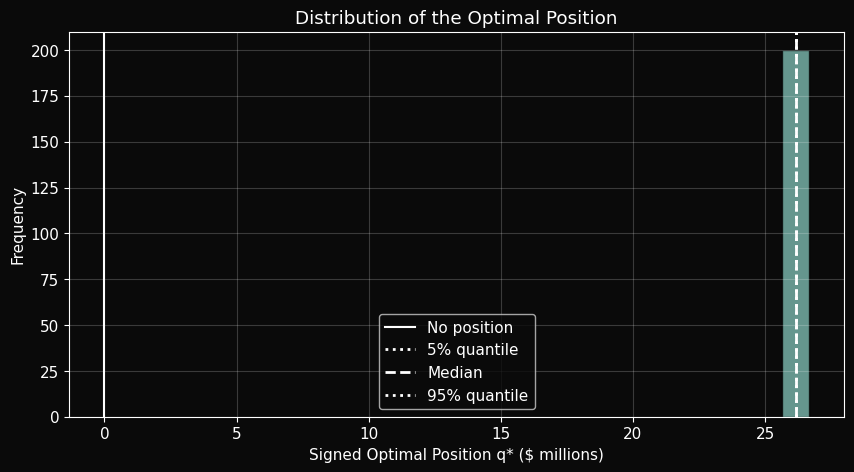

In [384]:
def plot_signed_position_distribution(
    q_distribution,
):
    '''
    Plot the empirical distribution of signed q*.
    '''

    q_star = (
        q_distribution[
            'q_star_usd'
        ]
        .dropna()
        .to_numpy()
    )


    if len(q_star) < 2:
        raise ValueError(
            'At least two q* observations are required.'
        )


    q05 = np.quantile(
        q_star,
        0.05,
    )

    q50 = np.quantile(
        q_star,
        0.50,
    )

    q95 = np.quantile(
        q_star,
        0.95,
    )


    fig, ax = plt.subplots(
        figsize=(10, 5)
    )


    ax.hist(
        q_star / 1_000_000,
        bins='fd',
        alpha=0.7,
        edgecolor='black',
    )


    # Zero separates shorts from longs
    ax.axvline(
        0,
        linewidth=1.5,
        label='No position',
    )


    ax.axvline(
        q05 / 1_000_000,
        linestyle=':',
        linewidth=2,
        label='5% quantile',
    )


    ax.axvline(
        q50 / 1_000_000,
        linestyle='--',
        linewidth=2,
        label='Median',
    )


    ax.axvline(
        q95 / 1_000_000,
        linestyle=':',
        linewidth=2,
        label='95% quantile',
    )


    ax.set_xlabel(
        'Signed Optimal Position q* ($ millions)'
    )

    ax.set_ylabel(
        'Frequency'
    )

    ax.set_title(
        'Distribution of the Optimal Position'
    )

    ax.legend()

    plt.show()

plot_signed_position_distribution(
    q_distribution
)


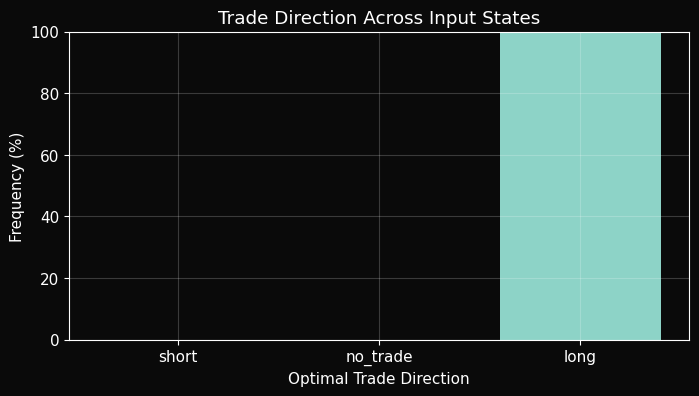

In [385]:
direction_order = [
    'short',
    'no_trade',
    'long',
]


direction_counts = (
    q_distribution[
        'direction'
    ]
    .value_counts(
        normalize=True
    )
    .reindex(
        direction_order,
        fill_value=0
    )
    .mul(100)
)


fig, ax = plt.subplots(
    figsize=(8, 4)
)


ax.bar(
    direction_counts.index,
    direction_counts.values,
)


ax.set_ylabel(
    'Frequency (%)'
)

ax.set_xlabel(
    'Optimal Trade Direction'
)

ax.set_title(
    'Trade Direction Across Input States'
)

ax.set_ylim(
    0,
    100,
)

plt.show()


## 6. Execution Horizon and Market Capacity

Position size and execution horizon interact.

Suppose a total position:

$$
q
$$

is executed evenly over:

$$
H
$$

trading days.

The dollar amount traded each day is:

$$
\frac{|q|}{H}.
$$

Using the same quadratic market-impact model, impact cost on one day is:

$$
\frac{\eta}{2V}
\left(
\frac{q}{H}
\right)^2.
$$

If the same amount is traded on each of the $H$ days, total impact is:

$$
H
\cdot
\frac{\eta}{2V}
\left(
\frac{q}{H}
\right)^2.
$$

Therefore:

$$
\boxed{
I(q,H)
=
\frac{\eta}{2HV}q^2.
}
$$

Equivalently, the effective impact coefficient becomes:

$$
\boxed{
\kappa_H
=
\frac{\eta}{HV}
=
\frac{\kappa_1}{H}.
}
$$

A longer execution horizon therefore reduces market impact under the equal-slicing assumption.

At the same time, available trading capacity increases:

$$
\boxed{
q_{\text{capacity}}
=
\phi HV.
}
$$

So increasing $H$ has two mechanical effects:

$$
H\uparrow
\Rightarrow
\text{lower impact},
$$

and:

$$
H\uparrow
\Rightarrow
\text{greater trading capacity}.
$$

This section does not yet claim that slower execution is always better. Waiting may reduce or change the investment signal. Optimizing $H$ therefore requires a return forecast that explicitly describes how the opportunity evolves with the execution horizon.


In [386]:
# ============================================================
# EXECUTION-HORIZON CONSISTENCY CHECKS
# ============================================================

kappa_1 = trade_inputs[
    'mean_impact_coefficient'
]


assert np.isclose(
    horizon_adjusted_impact_coefficient(
        kappa_1,
        execution_days=2,
    ),
    kappa_1 / 2,
)


assert np.isclose(
    horizon_adjusted_impact_coefficient(
        kappa_1,
        execution_days=10,
    ),
    kappa_1 / 10,
)


print(
    'Execution-horizon impact checks passed.'
)


Execution-horizon impact checks passed.


In [387]:
horizon_rows = []


for H in range(
    1,
    execution_days + 1,
):

    result_H = optimize_position(
        return_draws=return_draws,
        cost_draws=cost_draws,
        liquidity_draws=liquidity_draws,
        portfolio_value=portfolio_value,
        risk_aversion=risk_aversion,
        loss_budget=loss_budget,
        tail_probability=tail_probability,
        max_participation=max_participation,
        execution_days=H,
    )


    expected_capacity = (
        max_participation
        * H
        * trade_inputs['mean_adv_usd']
    )

    assert np.isclose(
        result_H['q_capacity_abs_usd'],
        expected_capacity,
    )


    horizon_rows.append(
        {
            'execution_days':
                H,

            'q_star_usd_m':
                abs(
                    result_H[
                        'q_star_usd'
                    ]
                ) / 1_000_000,

            'q_risk_usd_m':
                abs(
                    result_H[
                        'q_risk_usd'
                    ]
                ) / 1_000_000,

            'q_loss_usd_m':
                result_H[
                    'q_loss_abs_usd'
                ] / 1_000_000,

            'q_capacity_usd_m':
                result_H[
                    'q_capacity_abs_usd'
                ] / 1_000_000,

            'daily_adv_participation':
                result_H[
                    'daily_adv_participation'
                ],

            'binding_constraint':
                result_H[
                    'binding_constraint'
                ],
        }
    )


horizon_diagnostic = pd.DataFrame(
    horizon_rows
)


display(
    horizon_diagnostic
)

print(
    'Execution-horizon capacity checks passed.'
)


,execution_days,q_star_usd_m,q_risk_usd_m,q_loss_usd_m,q_capacity_usd_m,daily_adv_participation,binding_constraint
0,1,10.0000,10.8805,15.5841,10.0000,0.1000,daily_capacity
1,2,19.1686,21.2400,19.1686,20.0000,0.0958,loss_budget
2,3,21.2126,31.1153,21.2126,30.0000,0.0707,loss_budget
3,4,22.5788,40.5393,22.5788,40.0000,0.0564,loss_budget
4,5,23.5695,49.5425,23.5695,50.0000,0.0471,loss_budget
5,6,24.3258,58.1522,24.3258,60.0000,0.0405,loss_budget
6,7,24.9244,66.3939,24.9244,70.0000,0.0356,loss_budget
7,8,25.4112,74.2906,25.4112,80.0000,0.0318,loss_budget
8,9,25.8153,81.8634,25.8153,90.0000,0.0287,loss_budget
9,10,26.1566,89.1320,26.1566,100.0000,0.0262,loss_budget


Execution-horizon capacity checks passed.


### 6.1 Interpretation

The execution horizon changes the optimizer mechanically in two ways.

First:

$$
\kappa_H
=
\frac{\kappa_1}{H},
$$

so spreading a trade across more days reduces quadratic market impact under the equal-slicing assumption.

Second:

$$
q_{\text{capacity}}
=
\phi HV,
$$

so a longer horizon increases the amount that can be traded without exceeding the daily participation limit.

If the one-day trade is initially constrained by market capacity, increasing the execution horizon causes capacity to become less restrictive and the Expected-Shortfall loss budget becomes the binding constraint. However, these mechanics do **not** imply that the optimal execution horizon should be as long as possible, since a slower trade may lose part of the investment opportunity because the signal can decay or the event can be fully incorporated into prices.

The current model does not estimate this process, therefore:

$$
\boxed{
H\text{ remains an exogenous investor or event-design input.}
}
$$

A joint optimization:

$$
(q^*,H^*)
$$

would only be justified if the empirical application supplied a statistically supported relationship between execution time and the remaining return opportunity. For event-driven applications, the event timeline itself may provide the natural execution horizon, avoiding the need to impose an arbitrary signal-decay model.


## 7. Conclusion

I developed a general framework for translating an uncertain return opportunity into an implementable position.mThe model begins with predictive return draws:

$$
r_1,\ldots,r_N,
$$

without requiring a specific probability distribution. A signed position:

$$
q\in\mathbb R
$$

allows the optimizer to choose between a long position, a short position, and no trade, while implementation costs are represented by:

$$
C(q)
=
c|q|
+
\frac12\kappa q^2,
$$

where the first term represents proportional trading costs and the second represents convex market impact. Using a local CRRA certainty-equivalent approximation, the unconstrained position balances expected return against transaction costs, market impact and portfolio risk. The final position is then restricted by an Expected-Shortfall loss budget and a market-capacity limit.

Therefore the model produces:

$$
\boxed{
q^*
=
\text{optimal feasible signed position}.
}
$$

Because return, cost and liquidity inputs are generally estimated rather than perfectly known, the complete optimization can also be repeated across statistically plausible input states to obtain a distribution:

$$
q^{*(1)},\ldots,q^{*(B)}.
$$

This separates uncertainty about the investment opportunity from investor-policy choices such as risk aversion, loss tolerance, tail probability and maximum market participation. The execution horizon affects both market impact and trading capacity:

$$
\kappa_H=\frac{\kappa_1}{H},
\qquad
q_{\text{capacity}}=\phi HV.
$$

However, the model deliberately does not optimize the execution horizon without an empirical model of signal decay or horizon-specific returns.

Importantly, the model's outputs are conditional on the predictive return distribution, market inputs and investor policy supplied to it.
